In [6]:
import pandas as pd

df = pd.read_csv(r"C:\Users\HARSHIT SHARMA\TitanicProject\archive\titanic_converted.csv")
df.head()



,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [7]:
df.isnull().sum()


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [82]:
df['Age'].fillna(df['Age'].median(), inplace=True)


C:\Users\HARSHIT SHARMA\AppData\Local\Temp\ipykernel_8580\286566303.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)


In [84]:
# df.drop(columns=['Cabin'], inplace=True)

In [89]:
df['Embarked'].fillna(df['Embarked'].mode(), inplace=True)

C:\Users\HARSHIT SHARMA\AppData\Local\Temp\ipykernel_8580\689690975.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Embarked'].fillna(df['Embarked'].mode(), inplace=True)


In [96]:
print(df.duplicated().sum())  # duplicate rows count
df.drop_duplicates(inplace=True)  # permanently drop


0


In [101]:
df.drop(columns=['PassengerId','Name','Ticket'])


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22,1,0,7.2500,S
1,1,1,female,38,1,0,71.2833,C
2,1,3,female,26,0,0,7.9250,S
3,1,1,female,35,1,0,53.1000,S
4,0,3,male,35,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
886,0,2,male,27,0,0,13.0000,S
887,1,1,female,19,0,0,30.0000,S
888,0,3,female,0,1,2,23.4500,S
889,1,1,male,26,0,0,30.0000,C


count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

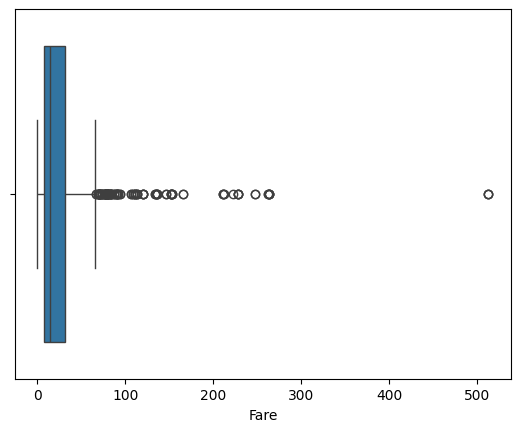

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df['Fare'])

df['Fare'].describe()

In [13]:
q1 = df['Fare'].quantile(0.25)  # Outlier hai ye
q3 = df['Fare'].quantile(0.75)  
iqr = q3 - q1                  
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
df = df[(df['Fare'] >= lower) & (df['Fare'] <= upper)]


In [102]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age              int64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Embarked        object
dtype: object

In [103]:
df['Age'] = df['Age'].fillna(0).astype(float)

df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Embarked        object
dtype: object

In [108]:
# df = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True)   iske baad changes hu hai

print(df.columns)


Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked'],
      dtype='object')


In [109]:
df.head()  # ye rha table with changes isse ml ko confusion se hatate hai


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [20]:
!pip install scikit-learn




[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [110]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[['Age', 'Fare']] = scaler.fit_transform(df[['Age', 'Fare']])


In [111]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,-0.101401,1,0,A/5 21171,-0.502445,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,0.808338,1,0,PC 17599,0.786845,C
2,3,1,3,"Heikkinen, Miss. Laina",female,0.126034,0,0,STON/O2. 3101282,-0.488854,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,0.637762,1,0,113803,0.420730,S
4,5,0,3,"Allen, Mr. William Henry",male,0.637762,0,0,373450,-0.486337,S


In [112]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1


In [113]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize
0,1,0,3,"Braund, Mr. Owen Harris",male,-0.101401,1,0,A/5 21171,-0.502445,S,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,0.808338,1,0,PC 17599,0.786845,C,2
2,3,1,3,"Heikkinen, Miss. Laina",female,0.126034,0,0,STON/O2. 3101282,-0.488854,S,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,0.637762,1,0,113803,0.420730,S,2
4,5,0,3,"Allen, Mr. William Henry",male,0.637762,0,0,373450,-0.486337,S,1


In [120]:
df.to_csv("PandasTitanic_cleaned.csv", index=False)
